# OGLE — Periodo de 50 estrellas por **Lomb–Scargle**

Pipeline análogo al notebook `OGLE_50_curvas_luz_SOLO.ipynb`:

1. Carga del catálogo `singlemode_variable_stars_sample.h5`.
2. Selección de **50 estrellas** con los features `RHJD`, `mag`, `mag_err` (limpieza + ordenamiento).
3. Cálculo del periodo de cada estrella con el **periodograma de Lomb–Scargle** (`astropy.timeseries.LombScargle`).
4. Salidas: tabla `periodos_lomb_scargle.csv`, figuras de curvas plegadas (50 individuales + grid resumen).

Coloca `singlemode_variable_stars_sample.h5` en la misma carpeta del notebook antes de ejecutar.

In [1]:
# Instalar si hace falta:
# python -m pip install numpy matplotlib pandas h5py astropy

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.timeseries import LombScargle

plt.rcParams["figure.dpi"] = 120

## 1. Configuración

In [2]:
DB_PATH = Path("singlemode_variable_stars_sample.h5")
OUTDIR = Path("resultados_OGLE_50_lomb_scargle")
OUTDIR.mkdir(exist_ok=True)

N_ESTRELLAS = 50
TIME_LABEL = "Tiempo (RHJD)"
MAG_LABEL = "Magnitud I"

# Rango de búsqueda de periodo (días)
P_MIN = 0.1
P_MAX = 10.0
SAMPLES_PER_PEAK = 10        # densidad de la grilla automática de Lomb–Scargle

print("Archivo esperado:", DB_PATH.resolve())

Archivo esperado: /home/user/minEnt/singlemode_variable_stars_sample.h5


## 2. Utilidades de carga / limpieza (idénticas al notebook original)

In [3]:
def clean_lightcurve(t, mag, err=None, min_points=20):
    """Limpia tiempo, magnitud y error sin desalinearlos."""
    t = np.asarray(t, dtype=float).ravel()
    mag = np.asarray(mag, dtype=float).ravel()

    if err is None:
        err = np.full_like(mag, np.nan, dtype=float)
    else:
        err = np.asarray(err, dtype=float).ravel()

    n = min(len(t), len(mag), len(err))
    t, mag, err = t[:n], mag[:n], err[:n]

    mask = np.isfinite(t) & np.isfinite(mag)
    t, mag, err = t[mask], mag[mask], err[mask]

    if len(t) < min_points:
        return None, None, None

    order = np.argsort(t)
    t, mag, err = t[order], mag[order], err[order]

    if np.isfinite(err).sum() == 0:
        err = None
    else:
        err[~np.isfinite(err)] = np.nan
        err[err <= 0] = np.nan
        if np.isnan(err).all():
            err = None
        else:
            med = np.nanmedian(err)
            err = np.where(np.isnan(err), med, err)

    return t, mag, err

## 3. Carga de las 50 estrellas OGLE

In [4]:
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"No encontré {DB_PATH}. Pon el archivo .h5 en la misma carpeta del notebook."
    )

with h5py.File(DB_PATH, "r") as file:
    star_codes = list(file["/"].keys())

print("Estrellas disponibles en el archivo:", len(star_codes))

selected_codes = star_codes[:N_ESTRELLAS]
ogle_curves = []

with h5py.File(DB_PATH, "r") as file:
    for name in selected_codes:
        star_data = pd.DataFrame(file[name][:])

        if not {"RHJD", "mag"}.issubset(star_data.columns):
            print(f"Saltando {name}. Columnas disponibles: {list(star_data.columns)}")
            continue

        t = star_data["RHJD"].to_numpy()
        mag = star_data["mag"].to_numpy()
        err = star_data["mag_err"].to_numpy() if "mag_err" in star_data.columns else None

        t, mag, err = clean_lightcurve(t, mag, err)
        if t is None:
            print(f"Saltando {name}: pocos puntos válidos.")
            continue

        ogle_curves.append({
            "name": name,
            "time": t,
            "mag": mag,
            "err": err,
        })

print(f"Curvas de luz cargadas: {len(ogle_curves)}")

Estrellas disponibles en el archivo: 140
Curvas de luz cargadas: 50


## 4. Método de Lomb–Scargle

El periodograma de Lomb–Scargle es el ajuste por mínimos cuadrados de un modelo sinusoidal
$y(t) = A\cos(2\pi f t) + B\sin(2\pi f t) + C$ para cada frecuencia $f$.
La potencia normalizada $P(f) \in [0, 1]$ mide cuánta varianza explica el modelo en esa frecuencia.

El periodo elegido es $\hat{P} = 1/\hat{f}$ con $\hat{f} = \arg\max_f P(f)$, sobre el rango
$[1/P_{\max},\,1/P_{\min}]$. Cuando hay errores fotométricos válidos se pasan a `LombScargle` como
pesos $1/\sigma_i^2$.

In [5]:
def lomb_scargle_period(
    t, mag, err=None,
    p_min=0.1, p_max=10.0,
    samples_per_peak=10,
):
    """Periodo por máximo del periodograma de Lomb-Scargle."""
    if err is not None and np.all(np.isfinite(err)) and np.all(err > 0):
        ls = LombScargle(t, mag, dy=err)
    else:
        ls = LombScargle(t, mag)

    f_min, f_max = 1.0 / p_max, 1.0 / p_min
    frequency, power = ls.autopower(
        minimum_frequency=f_min,
        maximum_frequency=f_max,
        samples_per_peak=samples_per_peak,
    )

    best_idx = int(np.argmax(power))
    best_freq = float(frequency[best_idx])
    best_power = float(power[best_idx])

    try:
        fap = float(ls.false_alarm_probability(best_power))
    except Exception:
        fap = np.nan

    return {
        "period": 1.0 / best_freq,
        "power": best_power,
        "fap": fap,
        "frequency": frequency,
        "power_spectrum": power,
    }

## 5. Cálculo de periodos para las 50 estrellas

In [6]:
results = []

for i, curve in enumerate(ogle_curves):
    out = lomb_scargle_period(
        curve["time"], curve["mag"], err=curve["err"],
        p_min=P_MIN, p_max=P_MAX,
        samples_per_peak=SAMPLES_PER_PEAK,
    )

    curve["period"] = out["period"]
    curve["power"] = out["power"]
    curve["fap"] = out["fap"]
    curve["frequency"] = out["frequency"]
    curve["power_spectrum"] = out["power_spectrum"]

    results.append({
        "name": curve["name"],
        "n_points": len(curve["time"]),
        "period_days": out["period"],
        "ls_power": out["power"],
        "false_alarm_prob": out["fap"],
    })

    print(f"[{i+1:02d}/{len(ogle_curves)}] {curve['name']:>4}  P = {out['period']:.6f} d   power = {out['power']:.4f}   FAP = {out['fap']:.2e}")

df_results = pd.DataFrame(results)
csv_path = OUTDIR / "periodos_lomb_scargle.csv"
df_results.to_csv(csv_path, index=False)
print("\nTabla guardada en:", csv_path)
df_results.head()

[01/50]   00  P = 4.717401 d   power = 0.9426   FAP = 0.00e+00


[02/50]   01  P = 1.833500 d   power = 0.7188   FAP = 6.89e-133


[03/50]   02  P = 0.102998 d   power = 0.9621   FAP = 1.96e-150
[04/50]   03  P = 0.523184 d   power = 0.6856   FAP = 4.85e-24


[05/50]   04  P = 0.305284 d   power = 0.9299   FAP = 3.32e-149


[06/50]   05  P = 0.531656 d   power = 0.6867   FAP = 5.16e-117


...

[47/50]   2e  P = 2.542952 d   power = 0.7837   FAP = 4.50e-121


[48/50]   2f  P = 0.275373 d   power = 0.9549   FAP = 0.00e+00


[49/50]   30  P = 3.403640 d   power = 0.2714   FAP = 4.59e-41


[50/50]   31  P = 0.863182 d   power = 0.0995   FAP = 7.19e-12

Tabla guardada en: resultados_OGLE_50_lomb_scargle/periodos_lomb_scargle.csv


,name,n_points,period_days,ls_power,false_alarm_prob
0,00,665,4.717401,0.942573,0.000000e+00
1,01,499,1.833500,0.718798,6.891017e-133
2,02,220,0.102998,0.962091,1.964666e-150
3,03,110,0.523184,0.685587,4.849030e-24
4,04,268,0.305284,0.929930,3.317394e-149


## 6. Distribución de los periodos hallados

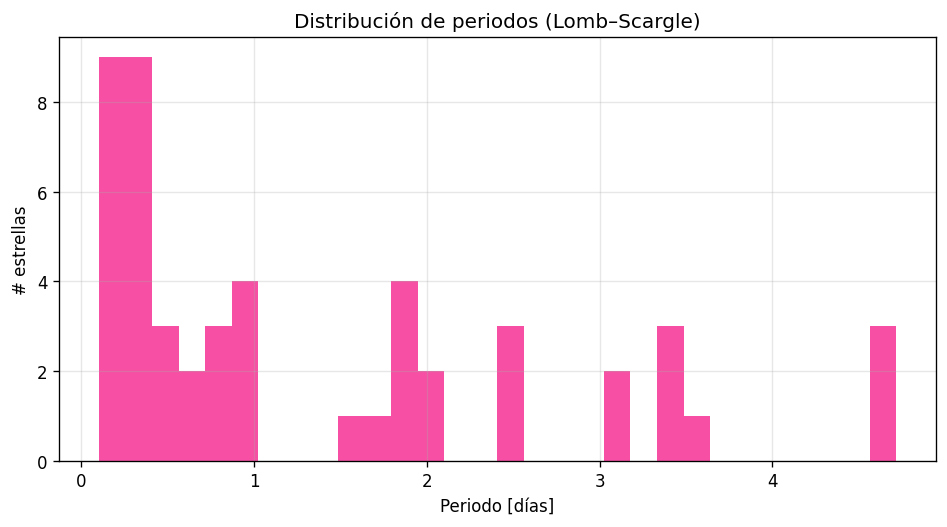

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_results["period_days"], bins=30, color="#F53093", alpha=0.85)
ax.set_xlabel("Periodo [días]")
ax.set_ylabel("# estrellas")
ax.set_title("Distribución de periodos (Lomb–Scargle)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUTDIR / "hist_periodos.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Curvas de luz plegadas: grid resumen de las 50 estrellas

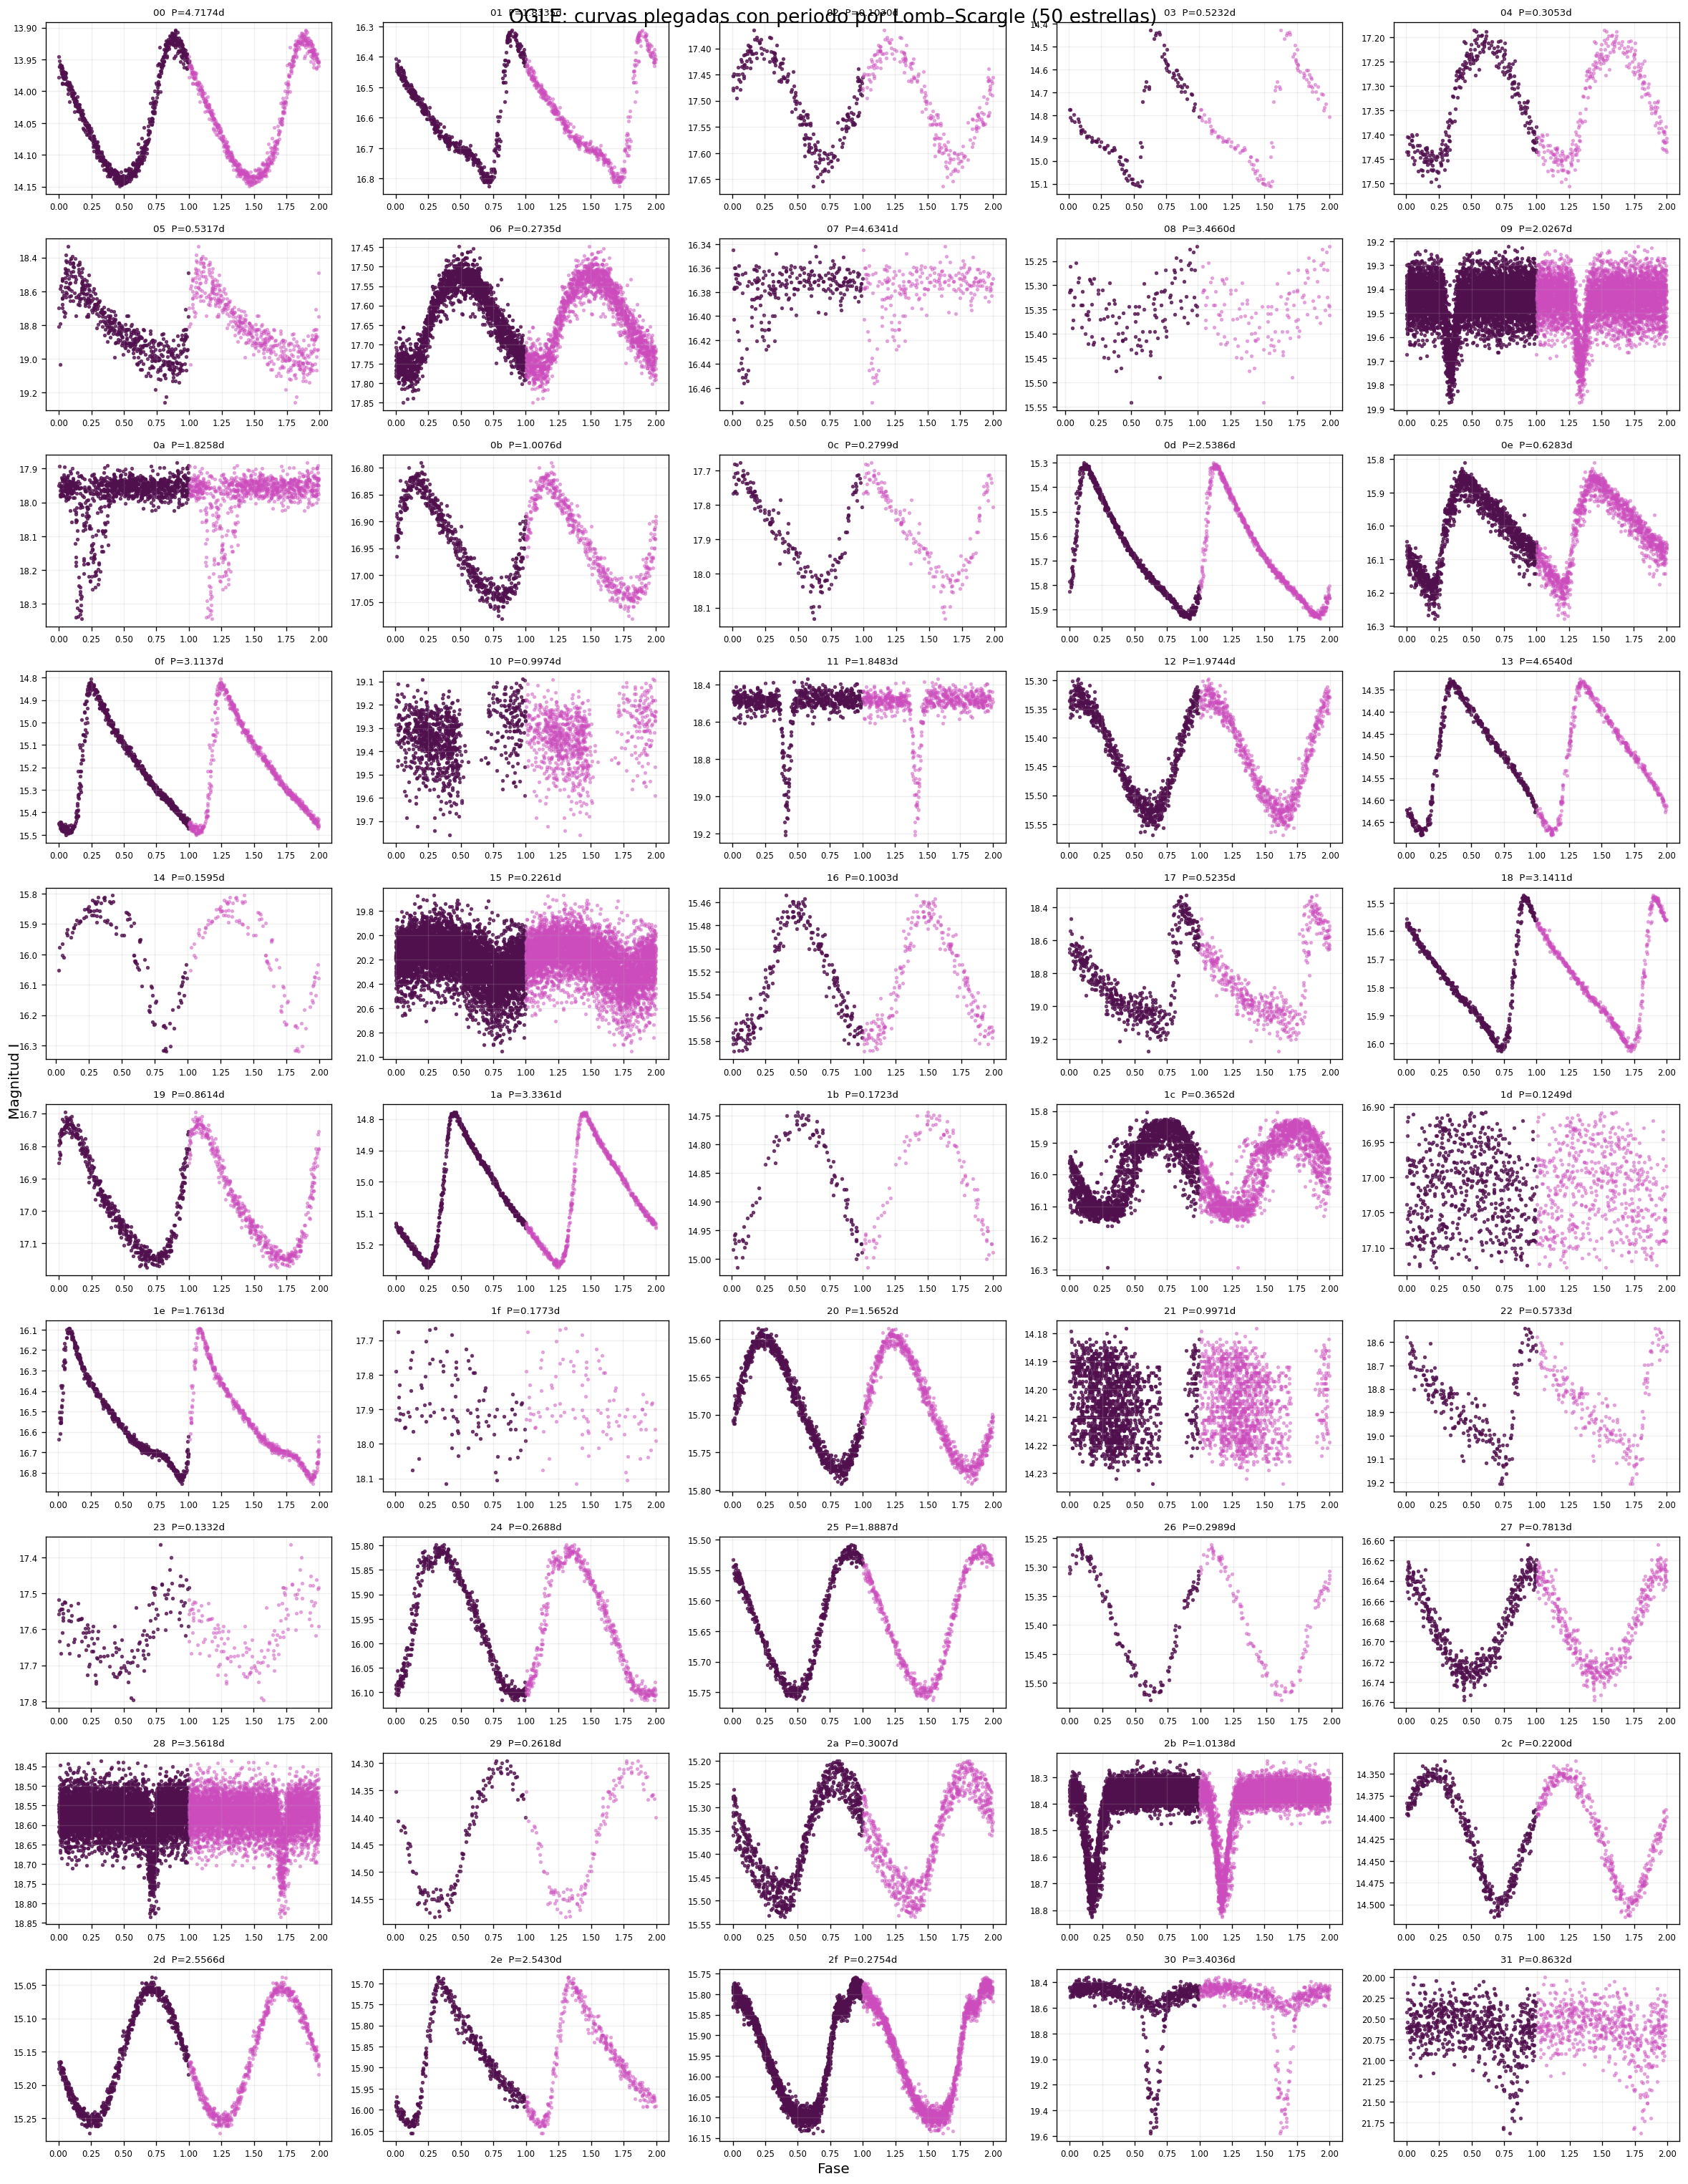

Grid plegado guardado en: resultados_OGLE_50_lomb_scargle/OGLE_50_curvas_plegadas_lombscargle_grid.png


In [8]:
def fold_curve(t, mag, period):
    phase = np.mod(t / period, 1.0)
    order = np.argsort(phase)
    return phase[order], mag[order]


n = len(ogle_curves)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 2.6 * nrows))
axes = np.ravel(axes)

for ax, curve in zip(axes, ogle_curves):
    phase, mag = fold_curve(curve["time"], curve["mag"], curve["period"])
    ax.scatter(phase, mag, s=5, alpha=0.75, color="#500f4d")
    ax.scatter(phase + 1, mag, s=5, alpha=0.4, color="#cc4cbd")
    ax.invert_yaxis()
    ax.set_title(f"{curve['name']}  P={curve['period']:.4f}d", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for ax in axes[n:]:
    ax.axis("off")

fig.supxlabel("Fase")
fig.supylabel(MAG_LABEL)
fig.suptitle(f"OGLE: curvas plegadas con periodo por Lomb–Scargle ({n} estrellas)", fontsize=16)
fig.tight_layout()
grid_path = OUTDIR / "OGLE_50_curvas_plegadas_lombscargle_grid.png"
fig.savefig(grid_path, dpi=300, bbox_inches="tight")
plt.show()
print("Grid plegado guardado en:", grid_path)

## 8. Figuras individuales: curva plegada + periodograma

In [9]:
individual_dir = OUTDIR / "individuales"
individual_dir.mkdir(parents=True, exist_ok=True)

for curve in ogle_curves:
    phase, mag_sorted = fold_curve(curve["time"], curve["mag"], curve["period"])
    periods_grid = 1.0 / curve["frequency"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Curva plegada
    axes[0].scatter(phase, mag_sorted, s=8, alpha=0.85, color="#500f4d")
    axes[0].scatter(phase + 1, mag_sorted, s=8, alpha=0.45, color="#cc4cbd")
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Fase")
    axes[0].set_ylabel(MAG_LABEL)
    axes[0].set_title(f"{curve['name']}  P = {curve['period']:.6f} d")
    axes[0].grid(alpha=0.3)

    # Periodograma
    axes[1].plot(periods_grid, curve["power_spectrum"], color="#870047", lw=0.7)
    axes[1].axvline(curve["period"], color="#F53093", ls="--", lw=1.2,
                    label=f"P̂ = {curve['period']:.4f} d")
    axes[1].set_xlabel("Periodo [días]")
    axes[1].set_ylabel("Potencia LS")
    axes[1].set_title("Periodograma Lomb–Scargle")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    safe_name = str(curve["name"]).replace("/", "_").replace(" ", "_")
    fig.savefig(individual_dir / f"OGLE_{safe_name}_lombscargle.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"Figuras individuales guardadas en: {individual_dir}")

Figuras individuales guardadas en: resultados_OGLE_50_lomb_scargle/individuales


---
**Resumen del pipeline**

- Carga 50 estrellas del `.h5` con los features `RHJD`, `mag`, `mag_err`.
- Limpia y ordena cada curva (descartando puntos no finitos / errores no positivos).
- Calcula el periodograma de Lomb–Scargle entre `1/P_MAX` y `1/P_MIN` con `samples_per_peak=SAMPLES_PER_PEAK`.
- El periodo final es $1/f$ con $f$ el máximo de la potencia normalizada.
- Reporta también `false alarm probability` como medida de significancia.
- Salidas: CSV con periodos, histograma de periodos, grid de 50 curvas plegadas, figuras individuales con periodograma.